In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import sys
import yaml
import os
import random
import time
from collections import defaultdict

os.environ["XLA_FLAGS"] = "--xla_gpu_deterministic_ops=true --xla_gpu_autotune_level=0"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

sys.path.append("..")

import wandb
# import jax
from dataclasses import asdict
import numpy as np
import pandas as pd
import tqdm
# from agents import agents
# from ml_collections import FrozenConfigDict
#  from utils.datasets import Dataset, GCDataset, HGCDataset
# from utils.evaluation import evaluate
# from utils.flax_utils import restore_agent, save_agent
# from utils.log_utils import CsvLogger, get_exp_name, get_wandb_video, setup_wandb
from utils.config import GCTTTConfig, load_config
import matplotlib.pyplot as plt
import importlib


In [21]:
# Load csv with pandas at "exp/antmaze_stitch/iql/ALL-GOALS-fomaml-200-1/irl-0.0003-lr-3e-07-test_loss.csv"
import re

def extract_lrs_from_path(path):
    """
    Extract meta_lr and inner_lr from the filename.
    Expected pattern: "irl-<inner_lr>-lr-<meta_lr>-test_loss.csv"
    """
    m = re.search(r"irl-([0-9.eE+-]+)-lr-([0-9.eE+-]+)", path)
    if m:
        inner_lr = m.group(1)
        meta_lr = m.group(2)
        return inner_lr, meta_lr
    else:
        return None, None

def plot_mean_test_loss(df, interval=100, inner_lr=None, meta_lr=None, ylim=None):
    """
    Plots mean test_loss for each inner_step,
    averaged over consecutive intervals of meta_step of given size.
    - interval=1: plot all loss values individually.
    - interval=len_of_steps: one global average.
    Allows inner_lr and meta_lr to be specified for plot title.
    Uses a red color gradient which gets more intense as inner_step increases.
    """
    df = df.copy()
    interval = max(1, interval)

    # Determine step groups by assigning each meta_step to an interval
    df["step_group"] = df["meta_step"] // interval

    plt.figure(figsize=(10, 6))
    inner_steps = [0, 10, 20, 50, 100, 200]

    # Generate a color gradient from light red to dark red
    cmap = plt.get_cmap("Reds")
    num_steps = len(inner_steps)
    # Skip the very lightest color for visibility, start at 0.2
    color_indices = np.linspace(0.2, 1.0, num_steps)
    red_colors = [cmap(idx) for idx in color_indices]

    for idx, inner in enumerate(inner_steps):
        df_inner = df[df['inner_step'] == inner]
        color = red_colors[idx]
        if interval == 1:
            # Plot every value individually (scatter)
            plt.scatter(df_inner["meta_step"], df_inner["test_loss"], s=10, label=f"inner_step={inner}", color=color)
        else:
            # Mean over each group
            mean_loss = df_inner.groupby("step_group")["test_loss"].mean()
            step_centers = mean_loss.index * interval + interval // 2
            plt.plot(step_centers, mean_loss.values, marker='o', label=f"inner_step={inner}", color=color)
    plt.legend()
    plt.xlabel("Step")
    plt.ylabel("mean test_loss")

    # Compose the plot title
    lr_str = ""
    if inner_lr is not None or meta_lr is not None:
        parts = []
        if meta_lr is not None:
            parts.append(f"meta_lr={meta_lr}")
        if inner_lr is not None:
            parts.append(f"inner_lr={inner_lr}")
        lr_str = " | " + ", ".join(parts)
    if interval == 1:
        plt.title(f"Test Loss per Step for Each inner_step (no averaging){lr_str}")
    elif interval >= df['meta_step'].max():
        plt.title(f"Global Mean Test Loss for Each inner_step{lr_str}")
    else:
        plt.title(f"Mean Test Loss per {interval} Steps for Each inner_step{lr_str}")

    if ylim is not None:
        plt.ylim(ylim)
    plt.show()


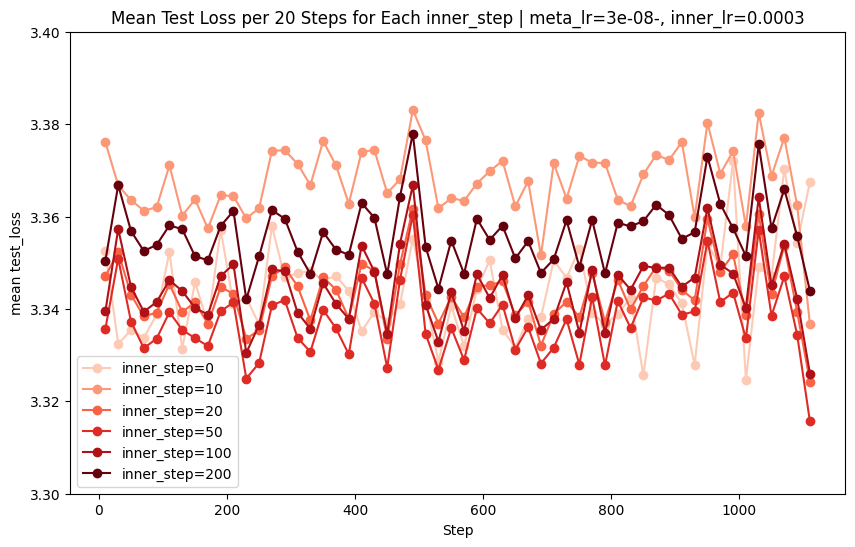

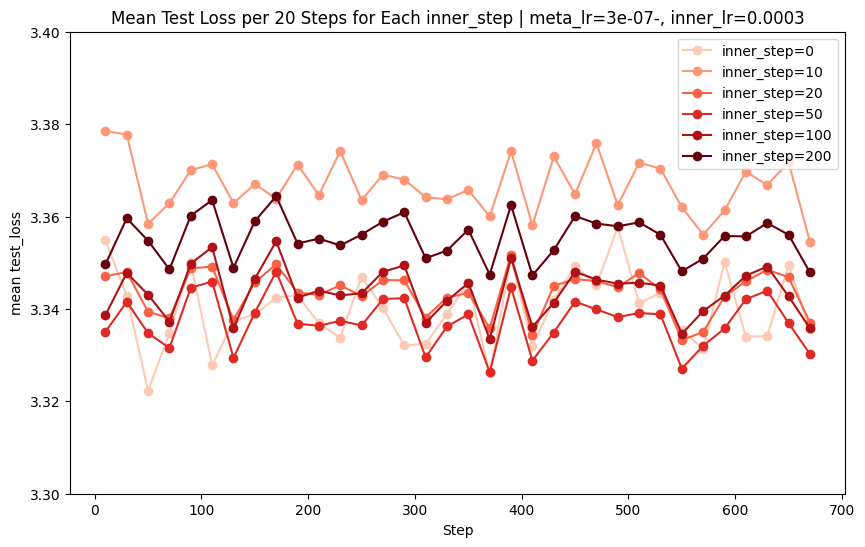

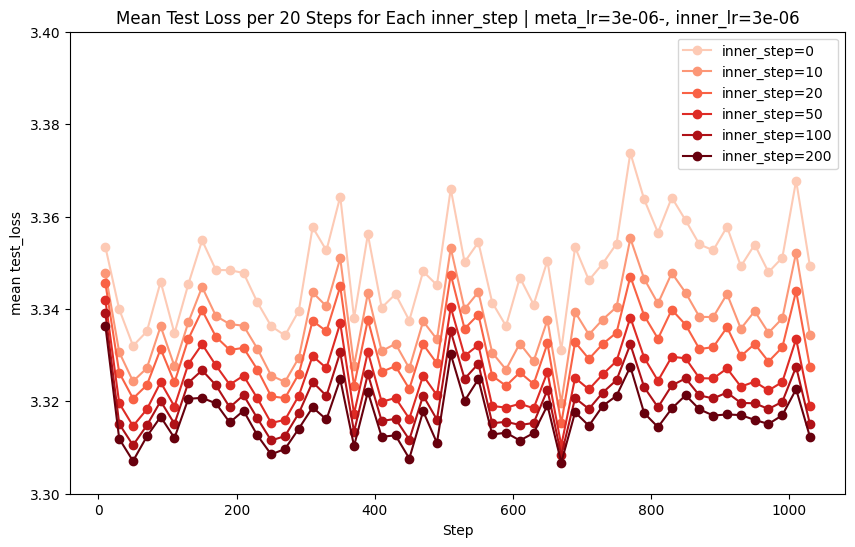

In [34]:
import glob

csv_folder = "../exp/antmaze_stitch/iql/ALL-GOALS-fomaml-200-1/"
csv_paths = glob.glob(f"{csv_folder}/*.csv")
for csv_path in csv_paths:
    df = pd.read_csv(csv_path)
    # Example usage: extract LRs from filename and provide to the plotting function.
    extracted_inner_lr, extracted_meta_lr = extract_lrs_from_path(csv_path)
    plot_mean_test_loss(df, interval=20, inner_lr=extracted_inner_lr, meta_lr=extracted_meta_lr, ylim=(3.3, 3.4))

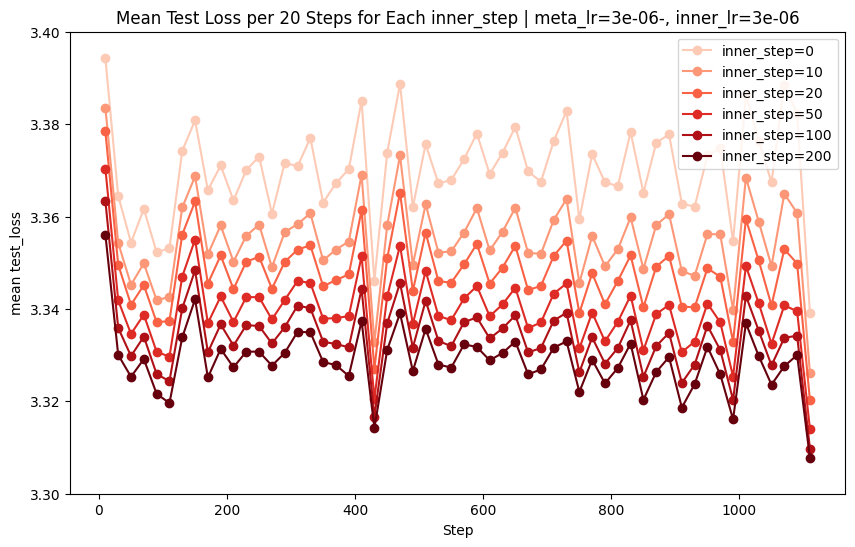

In [36]:
import glob

csv_folder = "../exp/antmaze_stitch/iql/TEST-GOALS-fomaml-200-1/"
csv_paths = glob.glob(f"{csv_folder}/*.csv")
for csv_path in csv_paths:
    df = pd.read_csv(csv_path)
    # Example usage: extract LRs from filename and provide to the plotting function.
    extracted_inner_lr, extracted_meta_lr = extract_lrs_from_path(csv_path)
    plot_mean_test_loss(df, interval=20, inner_lr=extracted_inner_lr, meta_lr=extracted_meta_lr, ylim=(3.3, 3.4))

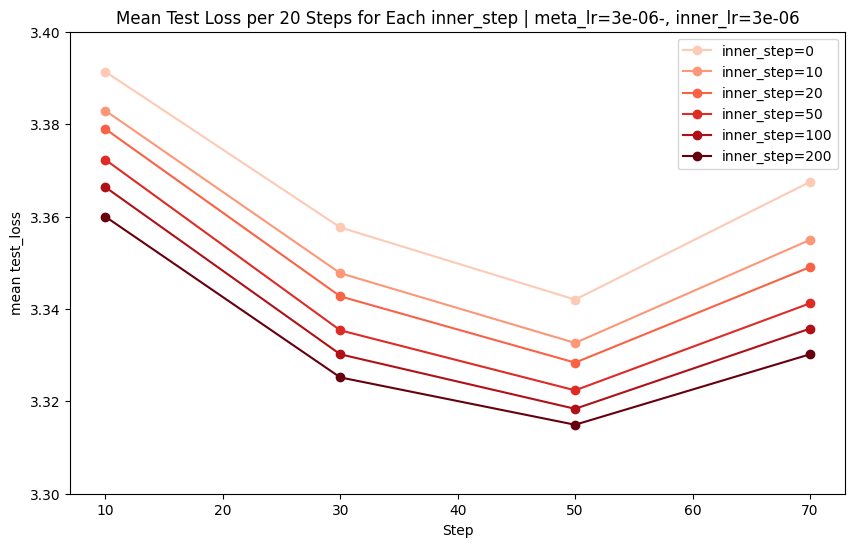

In [35]:
import glob

csv_folder = "../exp/antmaze_stitch/iql/avg-test-grad-TEST-GOALS-fomaml-200-1/"
csv_paths = glob.glob(f"{csv_folder}/*.csv")
for csv_path in csv_paths:
    df = pd.read_csv(csv_path)
    # Example usage: extract LRs from filename and provide to the plotting function.
    extracted_inner_lr, extracted_meta_lr = extract_lrs_from_path(csv_path)
    plot_mean_test_loss(df, interval=20, inner_lr=extracted_inner_lr, meta_lr=extracted_meta_lr, ylim=(3.3, 3.4))